In [21]:
!pip install pandas matplotlib numpy openpyxl gdown


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [22]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

In [23]:
url = "https://drive.google.com/uc?id=1BdbCbKRGkF8C6W5V7svqanLaGpfZ_Amm"
gdown.download(url, "../data/raw/data.xlsx", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1BdbCbKRGkF8C6W5V7svqanLaGpfZ_Amm
To: /Users/admin/Documents/GitHub/theasis/V2/data/raw/data.xlsx
100%|██████████| 26.1M/26.1M [00:10<00:00, 2.39MB/s]


'../data/raw/data.xlsx'

In [24]:
df = pd.read_excel("../data/raw/data.xlsx")
df.head()

,timestamp,FT-201,FT-801,FT-901,Mode,PT-901,PT-902,LS-901,PT-903,TT-901,TT-902,TT-903,TT-904,VSD-901_CORRENT,VSD-901_POWER,VSD-901_RPM,VSD-901_SPEED
0,2026-03-12 12:53:00,634.548645,296.557617,224.869797,9,-0.771195,0.008970,NaN,0.071065,NaN,NaN,NaN,NaN,47.484184,28.114202,1200.585938,100.019623
1,2026-03-12 12:54:00,632.899353,297.631836,10.839844,9,-1.011646,0.000362,NaN,0.004745,NaN,NaN,NaN,NaN,22.308279,7.962117,863.159180,77.610031
2,2026-03-12 12:55:00,638.020874,297.509766,463.183594,8,-0.555556,0.019893,NaN,0.132234,76.595055,77.636719,85.910378,86.062279,51.143913,31.321360,1199.267578,100.034714
3,2026-03-12 12:56:00,635.807251,297.363281,243.619781,8,-0.755498,0.009693,NaN,0.075694,76.562500,77.398003,86.523438,86.767578,47.609520,28.835020,1199.633789,100.022652
4,2026-03-12 12:57:00,631.380188,299.267578,96.191406,8,-0.996528,0.000506,NaN,0.008102,76.253250,77.121315,87.532547,87.098526,33.114746,18.881754,1200.659180,100.164757


In [25]:
print("Observations before cleaning: ", len(df))

df["timestamp"]     = pd.to_datetime(df["timestamp"])
df                  = df.sort_values("timestamp").reset_index(drop=True)
first_complete_idx  = df.notna().all(axis=1).idxmax()
df_cleaned          = df.iloc[first_complete_idx:].reset_index(drop=True)

print("Observations after cleaning: ", len(df_cleaned))

Observations before cleaning:  141982
Observations after cleaning:  141913


In [26]:
df_cleaned["time_diff"] = df_cleaned["timestamp"].diff()
gaps                    = df_cleaned[df_cleaned["time_diff"] > pd.Timedelta(minutes=1)]
total_time_lost         = gaps["time_diff"].sum() 

print(f"Total time missing: {total_time_lost}")
print(f"Nr of jumps found: {len(gaps)}")

Total time missing: 6 days 12:10:33.842000
Nr of jumps found: 161


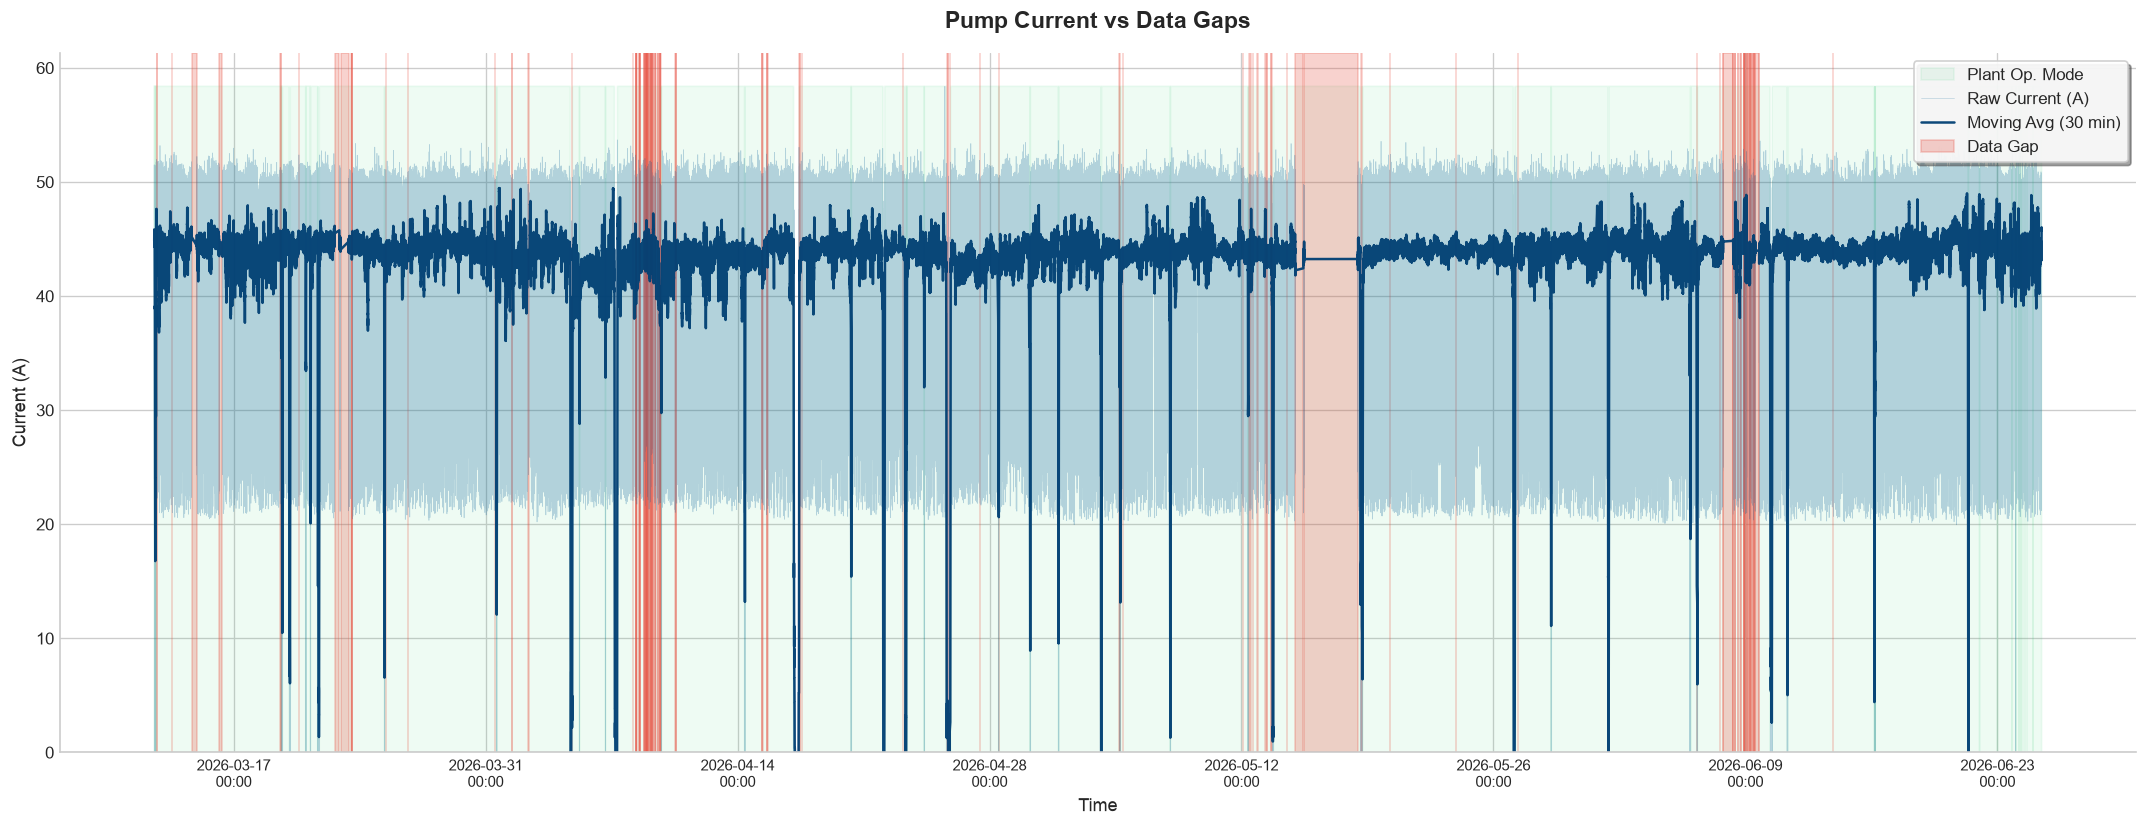

In [62]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 7), dpi=120)

plant_on_mask = df_cleaned["Mode"].isin([8, 9])
current       = df_cleaned["VSD-901_CORRENT"]
timestamps    = df_cleaned["timestamp"]

# Mask out gaps so the line breaks instead of connecting across them
current_masked = current.copy()
for idx, row in gaps.iterrows():
    end_gap   = row["timestamp"]
    start_gap = end_gap - row["time_diff"]
    gap_mask  = (timestamps >= start_gap) & (timestamps <= end_gap)
    current_masked[gap_mask] = float('nan')

# Moving average on masked signal
window_min = 30
ma = current_masked.rolling(window=window_min, center=True, min_periods=1).mean()

# Plant operating mode background
ax.fill_between(timestamps, 0, current.max(),
                where=plant_on_mask,
                color='#2ecc71', alpha=0.08, label='Plant Op. Mode')

# Raw signal (faint)
ax.plot(timestamps, current_masked,
        color='#005b96', linewidth=0.4, alpha=0.25, label='Raw Current (A)')

# Moving average (prominent)
ax.plot(timestamps, ma,
        color='#003f73', linewidth=1.5, alpha=0.95,
        label=f'Moving Avg ({window_min} min)')

# Data gaps
for idx, row in gaps.iterrows():
    end_gap   = row["timestamp"]
    start_gap = end_gap - row["time_diff"]
    ax.axvspan(start_gap, end_gap,
               color='#e74c3c', alpha=0.25,
               label='Data Gap' if idx == gaps.index[0] else "")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=0, fontsize=9)

ax.set_ylim(bottom=0)
ax.set_title("Pump Current vs Data Gaps", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Current (A)", fontsize=11)

ax.legend(loc='upper right', frameon=True, facecolor='white',
          framealpha=0.9, shadow=True, fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
bins                        = [0, 1.01, 5, 30, 120, 720, float('inf')]
labels                      = ['<=1 min', '1-5min','5-30 min', '30m-2h', '2h-12h', '>12h']
df_jumps                    = df_cleaned.sort_values("timestamp").copy()
df_jumps["gap_category"]    = pd.cut(df_jumps["time_diff"].dt.total_seconds() / 60, bins=bins, labels=labels)

print(df_jumps['gap_category'].value_counts().sort_index())


gap_category
<=1 min     141751
1-5min          86
5-30 min        55
30m-2h          11
2h-12h           7
>12h             2
Name: count, dtype: int64


In [58]:
all_buckets         = []

df_ops              = df_cleaned[df_cleaned["Mode"].isin([8,9])].copy()
df_ops              = df_ops.sort_values("timestamp")
is_big_gap          = df_ops["timestamp"].diff() > pd.Timedelta(minutes=30)
df_ops["bucket_id"] = is_big_gap.cumsum()

for bid, group in df_ops.groupby("bucket_id"):
    group                       = group.set_index("timestamp").sort_index()
    group_interp                = group.resample('min').asfreq()
    group_interp                = group_interp.interpolate(method='linear')

    group_interp["Mode"]        = group_interp["Mode"].ffill()
    group_interp["LS-901"]      = group_interp["LS-901"].ffill()  
    group_interp["bucket_id"]   = bid

    all_buckets.append(group_interp)


output_dir      = '../data/processed/clean'
count_exported  = 0
count_obs       = 0

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, bucket in enumerate(all_buckets):
    if len(bucket) >= 1000:

        filename = f"session_{i}.csv"
        file_path = os.path.join(output_dir, filename)
        
        bucket.to_csv(file_path)
        print(f"Generated the file {filename} ({len(bucket)} observations)")
        count_exported += 1
        count_obs += len(bucket)
    else:
        print(f"Ignored: Session {i} (only {len(bucket)} observations)")

print(f"Nr of buckets created: {len(all_buckets)}")
print(f"{count_exported} files exported.")
print(f"{count_obs} observations exported.")

Ignored: Session 0 (only 52 observations)
Generated the file session_1.csv (2900 observations)
Generated the file session_2.csv (1799 observations)
Generated the file session_3.csv (4763 observations)
Ignored: Session 4 (only 539 observations)
Generated the file session_5.csv (1606 observations)
Ignored: Session 6 (only 560 observations)
Ignored: Session 7 (only 6 observations)
Generated the file session_8.csv (1235 observations)
Ignored: Session 9 (only 102 observations)
Ignored: Session 10 (only 164 observations)
Ignored: Session 11 (only 4 observations)
Generated the file session_12.csv (2556 observations)
Generated the file session_13.csv (8938 observations)
Generated the file session_14.csv (2527 observations)
Generated the file session_15.csv (3270 observations)
Generated the file session_16.csv (3367 observations)
Generated the file session_17.csv (10175 observations)
Generated the file session_18.csv (1754 observations)
Generated the file session_19.csv (2096 observations)
Gene